<a href="https://colab.research.google.com/github/snaval29/ML-Projects/blob/main/MLPractical02_19_01_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder


In [4]:
df = pd.read_csv('/content/StudentPerformance.csv',encoding='latin-1')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [10]:
label_encoders = {}
for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column]= le.fit_transform(df[column])
        label_encoders[column]=le
print(df.head())

   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


In [12]:
#seperate features and target
X = df.iloc[:,:-1] #all column except target
y = df.iloc[:,-1] #target column

#Train-test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#Descision tree classifier
dt_model = DecisionTreeClassifier(criterion ='gini',random_state=42)
dt_model.fit(X_train,y_train)

#make predictions
y_pred = dt_model.predict(X_test)

#Evaluation
accuracy = accuracy_score(y_test,y_pred)
conf_matrix = confusion_matrix(y_test,y_pred)

print("Decesion tree Accuracy", accuracy)
print("Confusion Matrix:\n",conf_matrix)

Decesion tree Accuracy 0.136
Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]]


In [17]:
#Feature scaling (important for k-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#K-Means clustering
kmeans = KMeans(n_clusters=3,random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(df[['cluster']].head())

   cluster
0        1
1        2
2        1
3        1
4        0


In [20]:
comparison_table = pd.crosstab(df.iloc[:,-2],df['cluster'])
print("actual class vs K-Means Cluster Comparsion:\n")
print(comparison_table)

actual class vs K-Means Cluster Comparsion:

cluster            0  1  2
Performance Index         
10.0               0  0  1
11.0               2  2  1
12.0               3  1  4
13.0               1  5  7
14.0               3  1  3
...               .. .. ..
96.0               3  6  5
97.0               4  6  3
98.0               1  6  0
99.0               1  5  0
100.0              0  3  0

[91 rows x 3 columns]


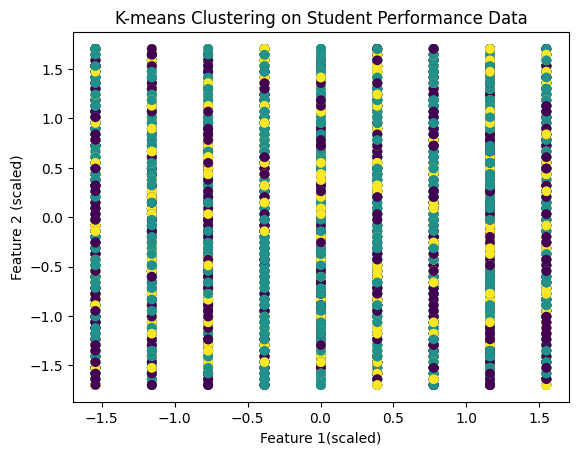

In [22]:
plt.figure()
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=df['cluster'])
plt.xlabel("Feature 1(scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.title("K-means Clustering on Student Performance Data")
plt.show()

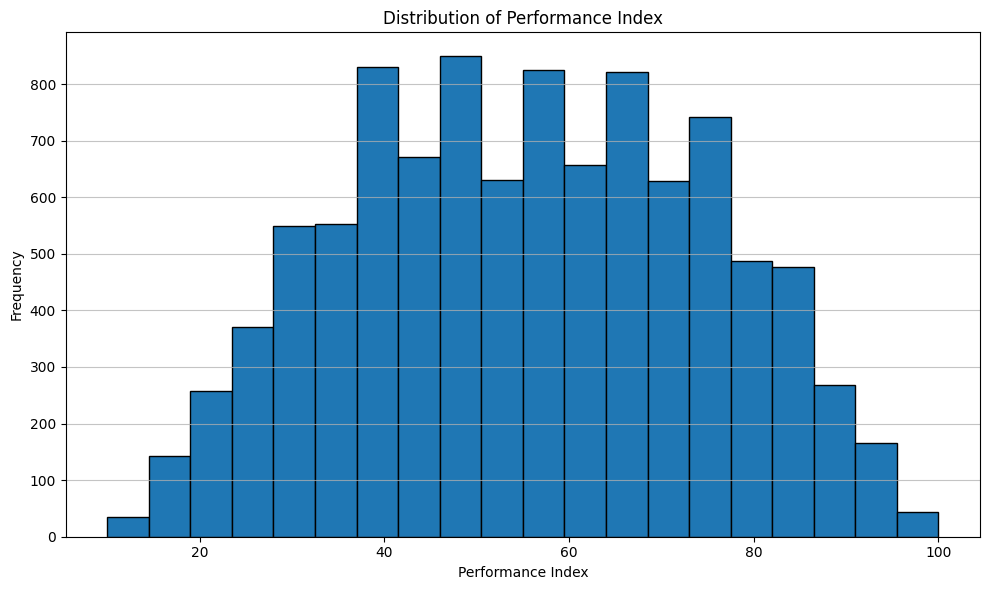

In [24]:
plt.figure(figsize=(10, 6))
plt.hist(df['Performance Index'], bins=20, edgecolor='black')
plt.title('Distribution of Performance Index')
plt.xlabel('Performance Index')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

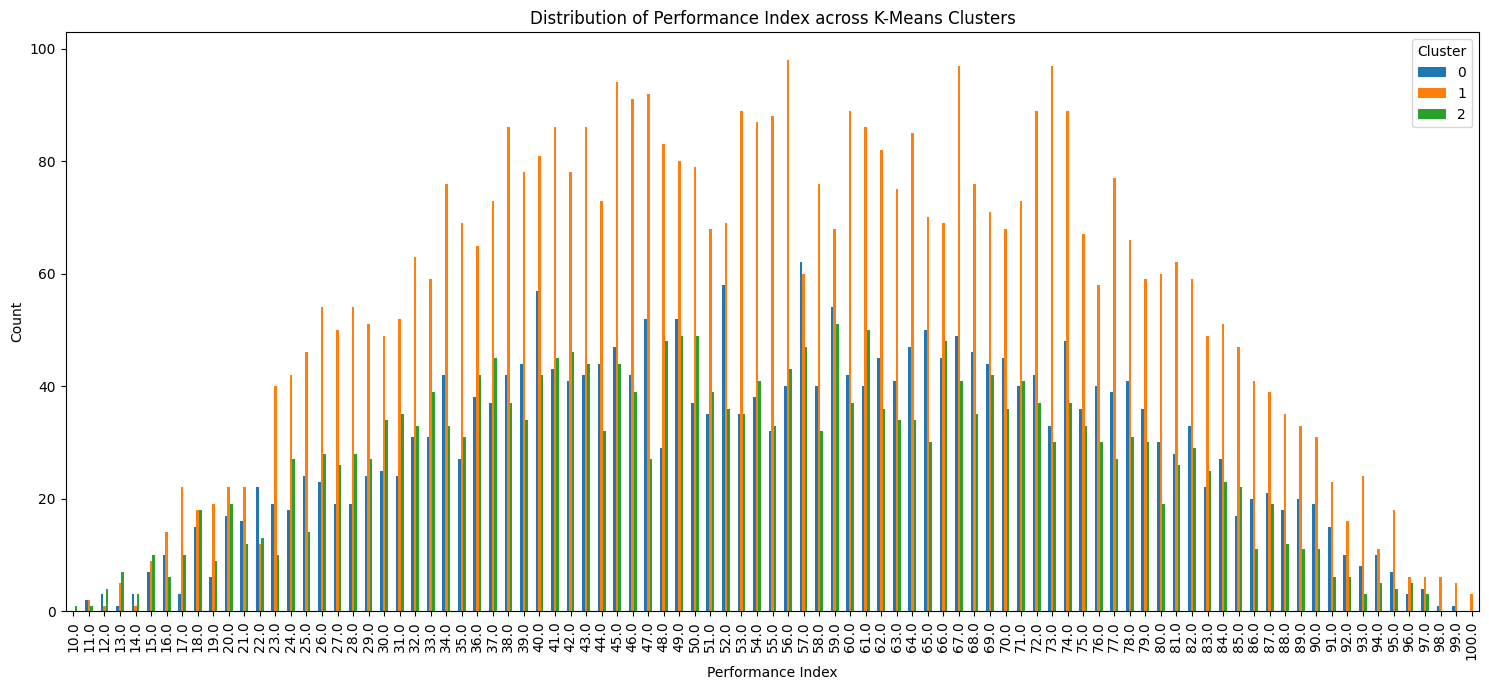

In [23]:
comparison_table.plot(kind='bar', figsize=(15, 7))
plt.title('Distribution of Performance Index across K-Means Clusters')
plt.xlabel('Performance Index')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()